# **Retrieve data from the CSV files** 
#### all tables concecated into one dataframe, calculate the mean per month and put it into one csv file called: mean_pm2.5_monthlyvalues.csv
In 1990, pm2.5 and pm10 weren't being tracked yet. So we'll start from 2016 onwards.


In [1]:
import pandas as pd
import numpy as np

urls = [ 
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2016/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2017/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2018/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2019/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2020/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2021/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2022/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2023/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2024/',
]
csv_suffix = '_PM10.csv' 
all_dfs = [] 


for base_url in urls:
    
    year = base_url.split('/')[-2]
    file_name = year + csv_suffix
    full_url = base_url + file_name 
    
   
    temp_df = pd.read_csv(
        full_url, 
        sep=';', 
        skiprows=5 
    )
    
    all_dfs.append(temp_df)
    print(f"loaded: {file_name}")

#Combine data into one df
main_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total instances: {len(main_df)}")


loaded: 2016_PM10.csv
loaded: 2017_PM10.csv
loaded: 2018_PM10.csv
loaded: 2019_PM10.csv
loaded: 2020_PM10.csv
loaded: 2021_PM10.csv
loaded: 2022_PM10.csv
loaded: 2023_PM10.csv
loaded: 2024_PM10.csv
Total instances: 6017665


In [3]:
import pandas as pd 
for x in main_df.columns:
    num_unique_values = main_df[x].nunique()
    print(f"Column '{x}' has {num_unique_values} unique values.")

#Unique location IDs for province mapping
sorted_unique_values = main_df['meetlocatie_id'].unique()
sorted_unique_values.sort()

print()
print("Sorted Unique meetreeks IDs:")
print(sorted_unique_values)

Column 'meetreeks_id' has 94 unique values.
Column 'meetlocatie_id' has 94 unique values.
Column 'bron_id' has 7 unique values.
Column 'accreditatienummer' has 4 unique values.
Column 'component' has 1 unique values.
Column 'matrix' has 1 unique values.
Column 'meetopstelling_id' has 3 unique values.
Column 'meetduur' has 1 unique values.
Column 'eenheid' has 1 unique values.
Column 'begindatumtijd' has 78912 unique values.
Column 'einddatumtijd' has 78912 unique values.
Column 'waarde' has 4414 unique values.
Column 'opm_code' has 0 unique values.

Sorted Unique meetreeks IDs:
['NL01483' 'NL01485' 'NL01486' 'NL01487' 'NL01488' 'NL01489' 'NL01491'
 'NL01493' 'NL01494' 'NL01495' 'NL01496' 'NL01497' 'NL01908' 'NL01912'
 'NL01913' 'NL10131' 'NL10133' 'NL10136' 'NL10138' 'NL10230' 'NL10235'
 'NL10236' 'NL10237' 'NL10240' 'NL10241' 'NL10243' 'NL10244' 'NL10246'
 'NL10247' 'NL10248' 'NL10318' 'NL10404' 'NL10418' 'NL10433' 'NL10437'
 'NL10442' 'NL10444' 'NL10445' 'NL10446' 'NL10449' 'NL10450'

# The nature and structure of the dataset. 
#### source: https://data.rivm.nl/data/luchtmeetnet/readme.pdf

#### Format of the data:
- The data is Time-Series. It consists of sequential measurements of PM10 concentration taken at specific dates and times across multiple monitoring stations in the Netherlands.

#### Number of instances:
- The exact number will be determined by code output (len(main_df)). Total amount of records in the combined csv dataset (len(df)): 6.666.197. This amount is excluding the headers in the first 5 rows of every dataset


#### Representativity and bias:
- The data is representative of all measuring statements in the netherlands at all times. Different monitoring networks have been used in order to gather the NO2 values.

#### Data structure:
- The data structure is Tabular. It is also relational in that each measurement belongs to a specific date, time, and location.


In [ ]:
import pandas as pd

data_dict = {
    'Variable Name': [
        'meetreeks',              
        'meetlocatie',            
        'bron_id',                
        'accredidatie',           
        'componenten',            
        'matrix',                 
        'meetopstelling_id',      
        'eenheid',                
        'begindatum',             
        'einddatum',              
        'waarde',                 
        'opm_code'                
    ],
    'Description or Meaning': [
        'identifier for the measurement series. ', 
        'identifier for the sampling location.', 
        'identifier for the source (i.e., the monitoring network)', 
        'accreditation number under which the measurements are carried out by a measuring network.', 
        'pollutant shorthand name, also used as an identifier. ', 
        'the environment which contains the pollutant. ', 
        'identifier for the measuring setup (i.e., the used measurement equipment)', 
        'the measurement duration of the measurements. ', 
        'start date time of the measurement.', 
        'end date time of the measurement.', 
        'measurement value', 
        'identifier for remarks.'
    ],
    'Data Type': [
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'Float64', 
        'string'
    ],
    'Units or Scale': [
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'YYYY-MM-DD HH:MM:SS', 
        'YYYY-MM-DD HH:MM:SS', 
        'micrograms per cubic meter', 
        'N/A'
    ],
    'Encoding': [
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'Int', 
        'N/A'
    ]
}

data_dictionary_df = pd.DataFrame(data_dict)
data_dictionary_df = data_dictionary_df.set_index('Variable Name')

data_dictionary_df

## potential data quality problems


In [ ]:
import pandas as pd

# Stel Pandas display-opties in om alle kolommen en rijen in de output te zien
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


# no scientific notation
pd.set_option('display.float_format', '{:.0f}'.format)

print(main_df.describe(include='all'))
print(main_df[['waarde']].describe())

nan_count = main_df.isnull().sum()
total_rows = len(main_df)
missing_data = nan_count[nan_count > 0]
missing_data = missing_data.sort_values(ascending=False)

if 'waarde' in missing_data.index:
    waarde_missing_info = missing_data.loc[['waarde']]
    print(waarde_missing_info)
else:
    print("There are no NAN values in the 'waarde' column.")

In [ ]:
main_df.info()



# Analyse the distribution for all variables

In [ ]:
!pip install scipy
!pip install numpy as np
!pip install matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt




[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#how many series (meetreeks_id) per location
contingency_table = pd.crosstab(
    index=main_df['meetlocatie_id'], 
    columns=main_df['meetreeks_id']
)

# Save to CSV file
contingency_table.to_csv('meetreeks_per_meetlocatie.csv', index=True)
print("Contingency table has been saved as 'meetreeks_per_meetlocatie.csv'")


In [ ]:
print("Total entries:", len(main_df['meetreeks_id']))
print("Unique meetreeks_id:", main_df['meetreeks_id'].nunique())
print("Missing values:", main_df['meetreeks_id'].isna().sum())


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'], errors='coerce')
main_df['begindatumtijd'].diff().describe()
plt.figure(figsize=(10,5))
main_df['begindatumtijd'].hist(bins=50)
plt.title('Histogram of begindatumtijd')
plt.xlabel('Date')
plt.ylabel('Count of measurements')
plt.show()

In [ ]:
print("Total entries:", len(main_df['begindatumtijd']))
print("Unique begindatumtijd:", main_df['begindatumtijd'].nunique())
print("Missing values:", main_df['begindatumtijd'].isna().sum())

In [ ]:
main_df.duplicated(subset=['begindatumtijd', 'meetreeks_id']).any()


In [ ]:
import pandas as pd
import numpy as np
ax= main_df.plot(
    kind='hist', 
    bins=100, 
    title='Distribution of NO2 values'
)

plt.ylabel("Frequency") 
plt.xlabel("PM10 value in micograms per cubic meter")

plt.show()

In [2]:
import pandas as pd
from scipy.stats import skew 


waarde_data = main_df['waarde']

skew_value = waarde_data.skew()


print(skew_value)

8.37402852675292


## Duplicate instances 

In [ ]:
import pandas as pd
duplicate_count = main_df.duplicated().sum()

if duplicate_count > 0:
    print(f"Found {duplicate_count} instances")
else:
    print("No duplicate instances found.")

## Outliers
In the beginning of the notebook, a preview of a potential data quality problem was shown. For this project, it is
advised not to remove them

In [ ]:
import pandas as pd

pd.set_option('display.float_format', '{:.4f}'.format)
print(main_df[['waarde']].describe())


In [ ]:
import pandas as pd
import numpy as np

#minimum value
min_waarde = main_df['waarde'].min()
min_waarde_frequentie = (main_df['waarde'] == min_waarde).sum()

#maximum value
max_waarde = main_df['waarde'].max()
max_waarde_frequentie = (main_df['waarde'] == max_waarde).sum()

#values less than or equal to 0
# are necessary 
# because they ensure the Boolean operation is completed before the attempts to count the results. 
nonpositive_values = (main_df['waarde'] <= 0).sum()


#minimum and frequencency
print(f"Minimum value in dataset: {min_waarde:.0f}")
print(f"Frequency minimum value: {min_waarde_frequentie}")

#maximum and frequencency
print(f"Maximum value in dataset: {max_waarde:.0f}")
print(f"Frequency of maximum value: {max_waarde_frequentie}")

#non_positive values
print(f"Frequency of No2 values below  or equal to 0: {nonpositive_values}")

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(11, 6))
plt.boxplot(
    main_df['waarde'], 
    vert=True, 
    patch_artist=True
)

plt.ylim(-40, 50)

plt.title("Box Plot: Distribution NO2 value")
plt.ylabel("NO2 value")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

sns.violinplot(
    y=main_df['waarde'],
    inner='quartile', 
    color='lightcoral',
    linewidth=1.5
)

plt.ylim(-200, 500) 

plt.title("Violin Plot: NO2 distribution (density)")
plt.ylabel("NO2 value")
plt.grid(True, axis='y', alpha=0.5)
plt.show()

## Seaborn visualizations

In [ ]:
!pip install seaborn


In [ ]:
import scipy.stats as stats
import seaborn as sns 

plt.figure(figsize=(10, 6))
sns.histplot(
    main_df['waarde'], 
    bins=100, 
    kde=True
)
plt.figure(figsize=(6, 6))
stats.probplot(
    main_df['waarde'], 
    dist="norm", 
    plot=plt
)

plt.title("QQ Plot: Controle on normality (NO2 Waarde)")
plt.show()

In [8]:
print(main_df['waarde'].skew())


9.191683555639585


## Distribution of the 0 and negative values according to meetset_id

In [2]:
import pandas as pd

non_positive_df = main_df[main_df['waarde'] <= 0]

if non_positive_df.empty:
    print("No values found that are 0 or less.")
else:
    # return a series
    error_counts = non_positive_df['meetreeks_id'].value_counts()
    
    # convert series to dataFrame
    error_table_df = error_counts.reset_index()
    
    print(error_table_df)

          meetreeks_id  count
0   NL10617_PM10_lucht   7468
1   NL10633_PM10_lucht   6379
2   NL10644_PM10_lucht   5852
3   NL10918_PM10_lucht   5759
4   NL10639_PM10_lucht   5066
..                 ...    ...
86  NL10243_PM10_lucht     16
87  NL01493_PM10_lucht     16
88  NL01486_PM10_lucht     10
89  NL01497_PM10_lucht      6
90  NL01912_PM10_lucht      4

[91 rows x 2 columns]


In [ ]:
import seaborn as sns
if 'begindatumtijd' in main_df.columns:
    main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'])

non_positive_df = main_df[main_df['waarde'] <= 0]

if non_positive_df.empty:
    print("No non positive values found. Bar chart cannot be created.")
else:
    # extract year from 'begindatumtijd' column
    nonpositive_years = non_positive_df['begindatumtijd'].dt.year

    # count errors per year
    fouten_per_jaar = nonpositive_years.value_counts()
    
    #make a dataframe for seaborn
    plot_df = fouten_per_jaar.reset_index(name='non positive values')
    plot_df.columns = ['year', 'non positive values']
    
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='year', 
        y='non positive values', 
        data=plot_df)
    plt.title('Count of Non-Positive PM10 Values per source file', fontsize=16)
    plt.xlabel('sourcefile', fontsize=14)
    plt.ylabel('Amount of non positive values', fontsize=14)
    plt.show()

# Cleaning Requirement: All values ≤0 must be imputed to positive values using fillna.
We used the fillna method to fill in the NAN values. This method locates every NAN value in the dataset and fills this instance with the previous instance from the same meetreeks_id. We used this method because the number of instances with NO2 values below or equal to 0 were a small amount in comparison to the total instances. The reason for this method is due to the fact that this datasource is a timeseries.

The result is that there are 2 NaN values left in the dataset. The reason for this is due to the fact that these are the first two measuring points of their respective meetreeks_id. 

These 2 NaN values will be deleted/ignored for the rest of the transformation and training of the model, because the percentage of NaN values is approximately 0,000005 percent



In [2]:
import numpy as np 
import pandas as pd 

count_non_positive = (main_df['waarde'] <= 0).sum()
print(f"Amount of non positive values: {count_non_positive}")

if count_non_positive > 0: 
    #Assign NaN to non positive values
    initial_total_nans = main_df['waarde'].isnull().sum()
    main_df.loc[main_df['waarde'] <= 0, 'waarde'] = np.nan 

    #impute the NAN values with positive values from the previous record with the same meetreeks_id
    main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')
    
print(f"Final NaN values in 'waarde': {main_df['waarde'].isnull().sum()}") 

Amount of non positive values: 164685


C:\Users\enock\AppData\Local\Temp\ipykernel_9540\482030983.py:13: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')
C:\Users\enock\AppData\Local\Temp\ipykernel_9540\482030983.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')


Final NaN values in 'waarde': 0


## Data transformation

add province

In [3]:
PM10_pvencoding = meetlocatie_provincie = {
    'NL01483': 'Zuid-Holland',
    'NL01485': 'Zuid-Holland',
    'NL01486': 'Zuid-Holland',
    'NL01487': 'Zuid-Holland',
    'NL01488': 'Zuid-Holland',
    'NL01489': 'Zuid-Holland',
    'NL01491': 'Zuid-Holland',
    'NL01493': 'Zuid-Holland',
    'NL01494': 'Zuid-Holland',
    'NL01495': 'Zuid-Holland',
    'NL01496': 'Zuid-Holland',
    'NL01497': 'Zuid-Holland',
    'NL01908': 'Zuid-Holland',
    'NL01912': 'Zuid-Holland',
    'NL01913': 'Zuid-Holland',
    'NL10131': 'Limburg',
    'NL10133': 'Limburg',
    'NL10136': 'Limburg',
    'NL10138': 'Limburg',
    'NL10230': 'Noord-Brabant',
    'NL10235': 'Noord-Brabant',
    'NL10236': 'Noord-Brabant',
    'NL10237': 'Noord-Brabant',
    'NL10240': 'Noord-Brabant',
    'NL10241': 'Noord-Brabant',
    'NL10243': 'Noord-Brabant', 
    'NL10244': 'Noord-Brabant',
    'NL10246': 'Noord-Brabant',
    'NL10247': 'Noord-Brabant',
    'NL10248': 'Noord-Brabant',
    'NL10318': 'Zeeland',
    'NL10404': 'Zuid-Holland',
    'NL10418': 'Zuid-Holland',
    'NL10433': 'Zuid-Holland',
    'NL10437': 'Zuid-Holland',
    'NL10442': 'Zuid-Holland',
    'NL10444': 'Zuid-Holland',
    'NL10445': 'Zuid-Holland',
    'NL10446': 'Zuid-Holland',
    'NL10449': 'Zuid-Holland',
    'NL10450': 'Zuid-Holland',
    'NL10538': 'Noord-Holland',
    'NL10545': 'Noord-Holland',
    'NL10547': 'Noord-Holland',
    'NL10549': 'Noord-Holland',
    'NL10550': 'Noord-Holland',
    'NL10617': 'Flevoland',
    'NL10631': 'Flevoland',
    'NL10633': 'Utrecht',
    'NL10636': 'Utrecht',
    'NL10639': 'Utrecht',
    'NL10641': 'Utrecht',
    'NL10644': 'Utrecht',
    'NL10722': 'Gelderland',
    'NL10738': 'Gelderland',
    'NL10741': 'Gelderland',
    'NL10807': 'Overijssel',
    'NL10818': 'Overijssel',
    'NL10918': 'Friesland',
    'NL10929': 'Drenthe',
    'NL10934': 'Friesland',
    'NL10937': 'Groningen',
    'NL49007': 'Noord-Holland',
    'NL49012': 'Noord-Holland',
    'NL49014': 'Noord-Holland',
    'NL49016': 'Noord-Holland',
    'NL49017': 'Noord-Holland',
    'NL49020': 'Noord-Holland',
    'NL49546': 'Noord-Holland',
    'NL49551': 'Noord-Holland',
    'NL49553': 'Noord-Holland',
    'NL49556': 'Noord-Holland',
    'NL49557': 'Noord-Holland',
    'NL49561': 'Noord-Holland',
    'NL49564': 'Noord-Holland',
    'NL49565': 'Noord-Holland',
    'NL49570': 'Noord-Holland',
    'NL49572': 'Noord-Holland',
    'NL49573': 'Noord-Holland',
    'NL49680': 'Flevoland',
    'NL49701': 'Noord-Holland',
    'NL49703': 'Noord-Holland',
    'NL49704': 'Noord-Holland',
    'NL50003': 'Limburg',
    'NL50004': 'Limburg',
    'NL50006': 'Limburg',
    'NL50010': 'Limburg',
    'NL53001': 'Noord-Brabant',
    'NL53004': 'Noord-Brabant',
    'NL53015': 'Noord-Brabant',
    'NL53016': 'Noord-Brabant',
    'NL53020': 'Noord-Brabant',
    'NL54004': 'Gelderland',
    'NL54010': 'Gelderland',    

}

# match province to meetlocatie_id
main_df['province'] = main_df['meetlocatie_id'].map(PM10_pvencoding)

# Select columns of df
dfpm10 = main_df[['province', 'waarde', 'meetlocatie_id']]
print(dfpm10.head(10))

       province  waarde meetlocatie_id
0  Zuid-Holland    52.0        NL01483
1  Zuid-Holland    33.9        NL01483
2  Zuid-Holland    31.9        NL01483
3  Zuid-Holland    27.1        NL01483
4  Zuid-Holland    19.4        NL01483
5  Zuid-Holland    13.9        NL01483
6  Zuid-Holland    13.9        NL01483
7  Zuid-Holland    17.7        NL01483
8  Zuid-Holland    15.1        NL01483
9  Zuid-Holland    14.3        NL01483


make a df with monthly average values, province and year_month. On top of that, format the year_month column and not the average PM10 value yet this will happen at the end after the regression because of the fact that rounded integers can't be used to train the model

In [4]:
main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'])

#Extract the year from the datetime column
main_df['Jaar'] = main_df['begindatumtijd'].dt.year

#Group by year and province, then calculate the mean NO₂ value
dfpm10 = (
    main_df.groupby(['Jaar', 'province'])['waarde']
    .mean()
    .reset_index()
)

#Rename columns
dfpm10.columns = ['Year', 'province', 'Average PM 10 Value']

#Correct data type for 'Year' column
dfpm10['Year'] = dfpm10['Year'].astype(int)

#Display the first few rows
print(dfpm10.head())

   Year    province  Average PM 10 Value
0  2016     Drenthe            15.895986
1  2016   Flevoland            17.727549
2  2016   Friesland            17.120922
3  2016  Gelderland            20.322640
4  2016   Groningen            22.964547


In [15]:
a = dfpm10['Average PM.10 Value']
c = abs(a.min())

In [16]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


shift = a + c + 0.001
log_x = np.log(shift)  
print(log_x)

0      3.362673
1      3.424191
2      3.404232
3      3.505344
4      3.581706
         ...   
103    3.355937
104    3.304256
105    3.361108
106    3.361440
107    3.389814
Name: Average PM.10 Value, Length: 108, dtype: float64


In [17]:
log_x.skew()

np.float64(-0.0008465203636900886)

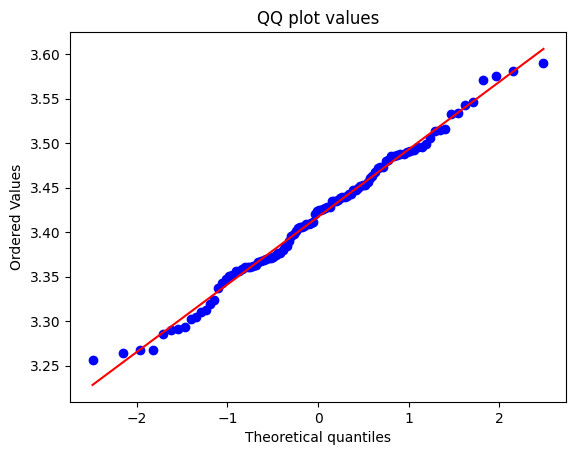

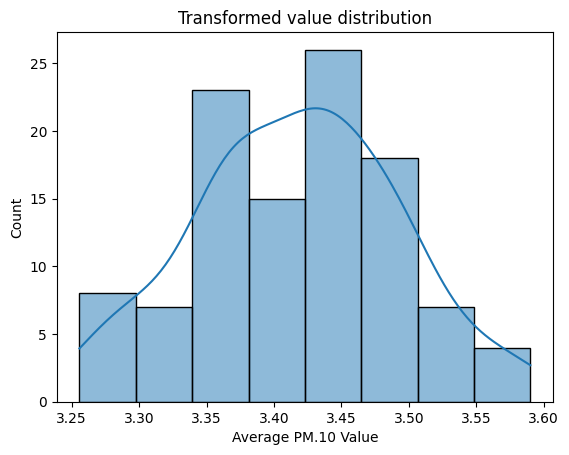

In [9]:
import seaborn as sns 

stats.probplot(log_x, dist="norm", plot=plt)
plt.title("QQ plot values")
plt.show()

sns.histplot(log_x,kde=True)
plt.title("Transformed value distribution")
plt.show()

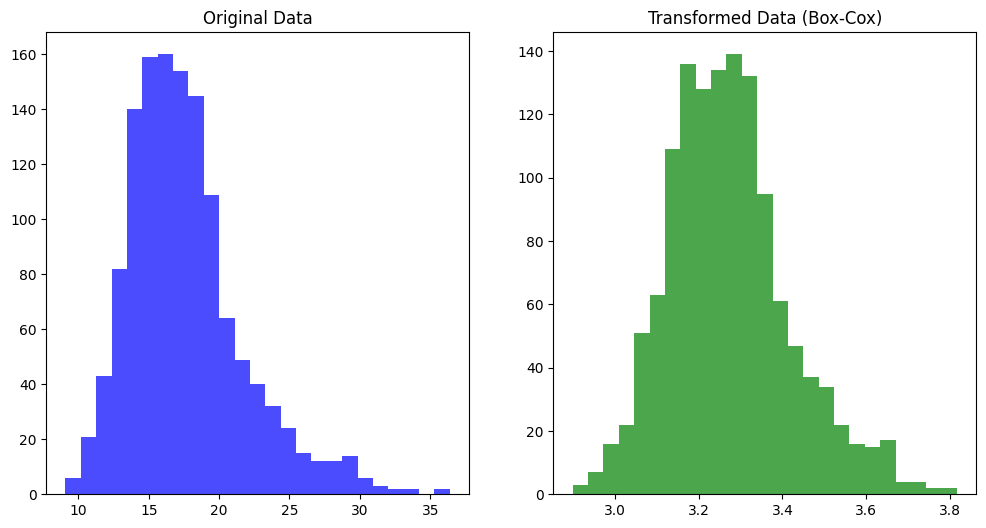

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(a, bins=25, color='blue', alpha=0.7)
plt.title('Original Data')

plt.subplot(1, 2, 2)
plt.hist(log_x, bins=25, color='green', alpha=0.7)
plt.title('Transformed Data (Box-Cox)')

plt.show()

In [18]:
%pip install scikit-learn
from sklearn.preprocessing import StandardScaler

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


#### Since the log_x values are stored as series instead of dataframe, we need to reshape the data. Since we mainly want to use numerical data for the prediction part we scale them so that they will have the same impact on the clustering algorithms (which are sensitive to different data scales). Moreover, it is less sensitive to outliers (compared to minmax() scaling), helping us reduce the impact of these outliers. 
- https://stackoverflow.com/questions/35723472/how-to-use-sklearn-fit-transform-with-pandas-and-return-dataframe-instead-of-num

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize the log-transformed NO₂ values
standardizePM10 = StandardScaler().fit_transform(log_x.values.reshape(-1, 1))

# Build a  DataFrame instead of a Series
dfstandardizationPM10 = pd.DataFrame({
    'Year': dfpm10['Year'].values,
    'province': dfpm10['province'].values,
    'Standardized_PM10': standardizePM10.flatten()
})

# result
print(dfstandardizationPM10.head())

   Year    province  Standardized_PM10
0  2016     Drenthe          -0.729356
1  2016   Flevoland           0.094076
2  2016   Friesland          -0.173080
3  2016  Gelderland           1.180319
4  2016   Groningen           2.202438
Skewness of standardized PM10: -0.0008465203637052336


## Linear regression 

Year_month should be correlated with average no2 value. You should see a negative correlation. The average value decreases as time goes on.

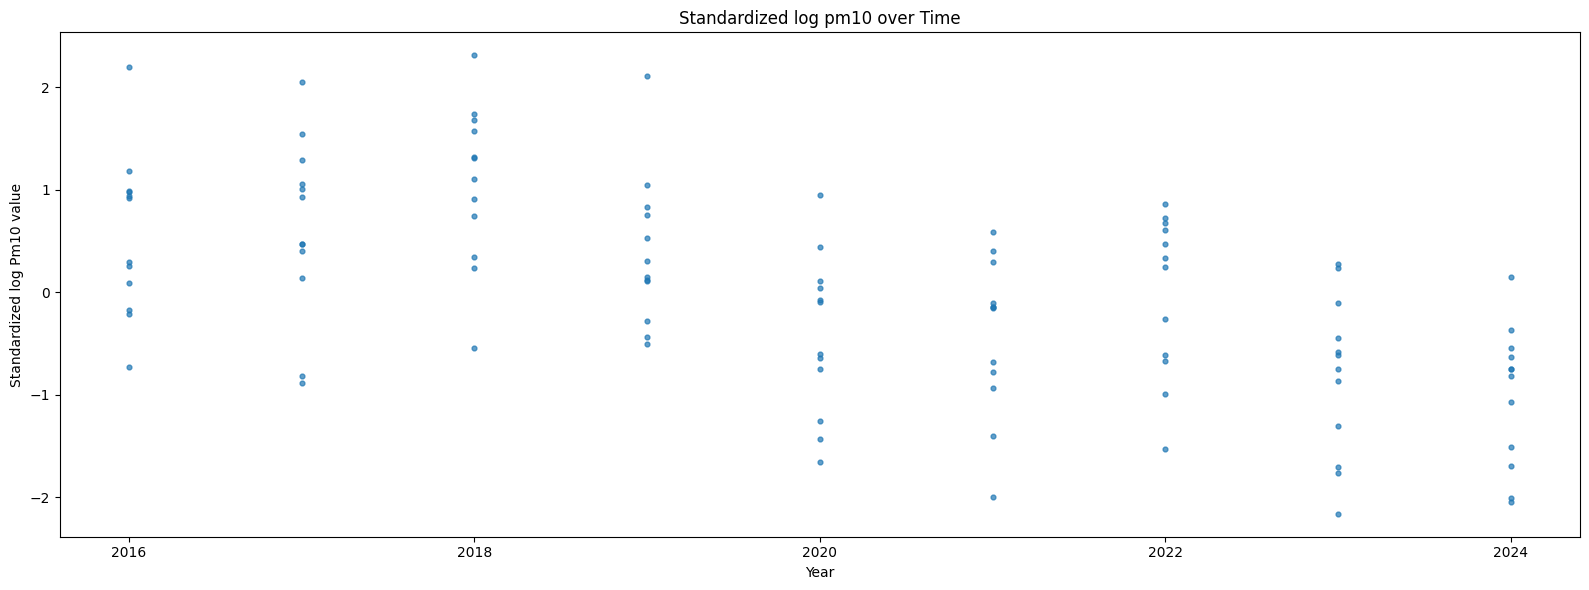

In [ ]:
import matplotlib.pyplot as plt

# make sure it's numeric
dfpm10['Year'] = dfpm10['Year'].astype(int)

plt.figure(figsize=(16, 6))
plt.scatter(
    dfpm10['Year'],
    dfpm10['Standardized_PM10']
)

plt.title("pm10 over Time")
plt.xlabel("Year")
plt.ylabel("Pm10 value")

years = sorted(dfpm10['Year'].unique())

plt.show()


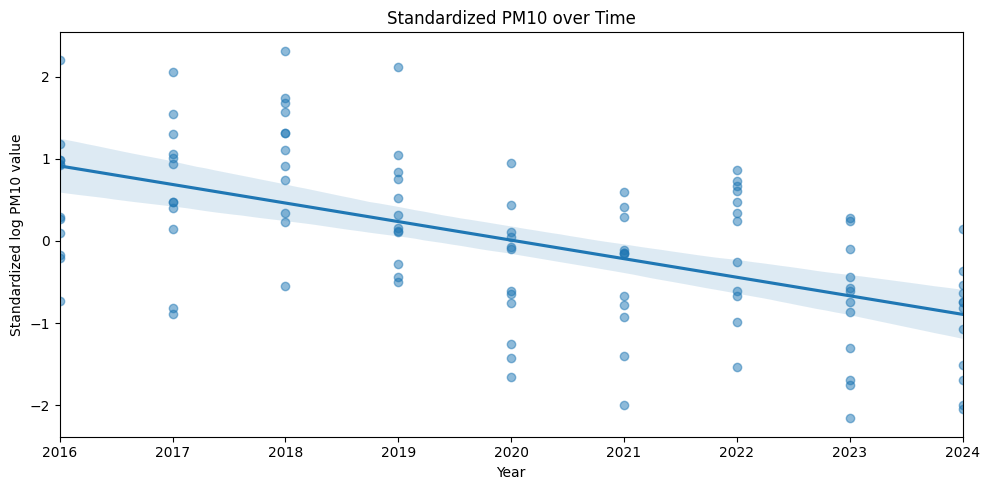

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(10, 5))
ax = plt.gca()

sns.regplot(
    x='Year',
    y='Standardized_PM10',
    data=dfstandardizationPM10,
    scatter_kws={'alpha': 0.5},
    robust=True,
    ax=ax
)

# Labels and formatting
ax.set_title("Standardized PM10 over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Standardized log PM10 value")

years = sorted(dfstandardizationPM10['Year'].unique())

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

df_yearly = (
    dfpm10
    .groupby(['Year', 'province'], as_index=False)['Average PM 10 Value']
    .mean()
    .dropna()


# features and target
X = df_yearly[['Year', 'province']]
y = df_yearly['Average PM 10 Value']  #raw value target 

# necessary if you include “province” as a predictor in model. Because scikit can't handle string data
preprocessor = ColumnTransformer(
    transformers=[
        ('province', OneHotEncoder(drop='first'), ['province'])
    ],
    remainder='passthrough'   #keeps Year
)

# pipeline
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

In [7]:
import pandas as pd

# Load the monthly predictions
monthly = pd.read_csv('predicted_PM10values_mean_monthly_2025_2031.csv')

# Extract the year from Year_Month
monthly['Year'] = monthly['Year_Month'].str[:4].astype(int)

# Group by year and province, then take the mean
yearly = (
    monthly.groupby(['Year', 'province'], as_index=False)['Average_predicted_PM10']
    .mean()
)

# Round the predicted values to integers
yearly['Average_predicted_PM10'] = yearly['Average_predicted_PM10'].round(0).astype('Int64')

# Save the result
yearly.to_csv('predicted_PM10values_yearly_2025_2031.csv', index=False)

print("Saved: predicted_PM10values_yearly_2025_2031.csv")
print(yearly.head(12))

Saved: predicted_PM10values_yearly_2025_2031.csv
    Year       province  Average_predicted_PM10
0   2025        Drenthe                      12
1   2025      Flevoland                      14
2   2025      Friesland                      13
3   2025     Gelderland                      16
4   2025      Groningen                      18
5   2025        Limburg                      15
6   2025  Noord-Brabant                      15
7   2025  Noord-Holland                      16
8   2025     Overijssel                      13
9   2025        Utrecht                      14
10  2025        Zeeland                      15
11  2025   Zuid-Holland                      16


#### Validation of the regression model with Time series validation
https://www.w3schools.com/python/python_ml_cross_validation.asp

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=10)

scores_yearly = cross_val_score(model, X, y, cv=tscv, scoring='r2')

# results
print("Yearly R2 per fold:", scores_yearly)
print("Mean Yearly R2:", scores_yearly.mean())
print("Number of folds used:", len(scores_yearly))


Yearly R2 per fold: [ 0.69481292 -1.4266229   0.01543704  0.57707566  0.70647515]
Mean Yearly R2: 0.11343557357537604
Number of folds used: 5


Residuals and predicted vs actuals

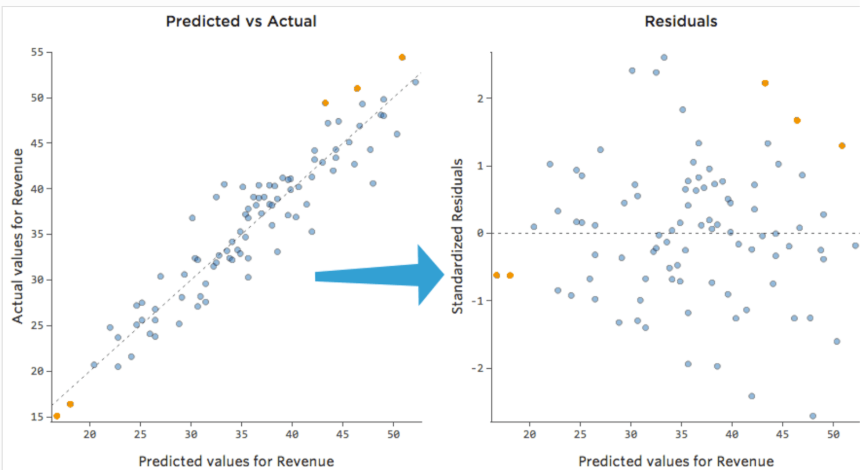

In [ ]:
import matplotlib.pyplot as plt  
import numpy as np

y_pred = model.predict(X)

# Fit  model 
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate MSE
MSE = np.square(y - y_pred).mean()

# Calculate Root Mean Squared Error 
RMSE = np.sqrt(MSE)

print(f"Mean Squared Error: {MSE}")
print(f"Root Mean Squared Error: {RMSE}")


NameError: name 'model' is not defined

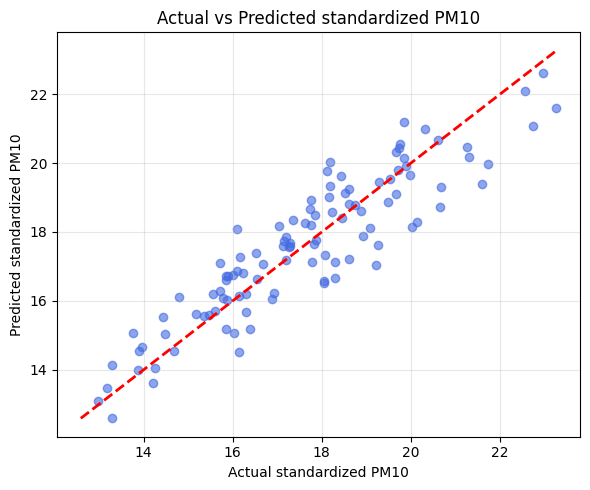

Mean Squared Error (MSE): 0.9129
Root Mean Squared Error (RMSE): 0.9555


In [ ]:
import matplotlib.pyplot as plt

# Fit  model and get predictions
model.fit(X, y)
y_pred = model.predict(X)

# Determine dynamic limits
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

# Plot Actual vs Predicted standardized PM10
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred, alpha=0.6, color='royalblue')

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual standardized PM10")
plt.ylabel("Predicted standardized PM10")
plt.title("Actual vs Predicted standardized PM10")
plt.show()

# Calculate MSE
MSE = np.square(y - y_pred).mean()

# Calculate Root Mean Squared Error 
RMSE = np.sqrt(MSE)

print(f"Mean Squared Error (MSE): {MSE:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")